# **Student Dropout Prediction**

### **Importing Libraries and Data**
At this stage, we import the necessary libraries for data analysis (pandas, numpy), visualization (matplotlib, seaborn), and machine learning model implementation (scikit-learn). Next, the "Student Dropout Dataset" is loaded, followed by an overview of its structure (data types, number of records, and missing values).

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
# Loading the dataset
df = pd.read_csv('student_dropout_dataset.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

### **Exploratory Data Analysis (EDA)**
In this section, a detailed data analysis is performed to identify patterns and correlations. The distribution of the target variable (Dropout) is examined to check for class imbalance, and correlation matrices (Heatmaps) are used to highlight the features that most significantly influence a student's decision to drop out.

        Student_ID          Age  Family_Income  Study_Hours_per_Day  \
count  10000.00000  10000.00000    9500.000000          9500.000000   
mean    5000.50000     21.02606   38377.247474             4.014592   
std     2886.89568      2.13981   20496.232179             1.295450   
min        1.00000     17.00000   25000.000000             0.500000   
25%     2500.75000     19.50000   25000.000000             3.160000   
50%     5000.50000     21.00000   29740.500000             4.000000   
75%     7500.25000     22.50000   44520.000000             4.870000   
max    10000.00000     29.60000  316601.000000             8.980000   

       Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  \
count      10000.00000           10000.000000          10000.00000   
mean          81.73683               1.799700             30.17926   
std            8.22093               1.344307             11.91887   
min           38.20000               0.000000              5.00000   
25%       

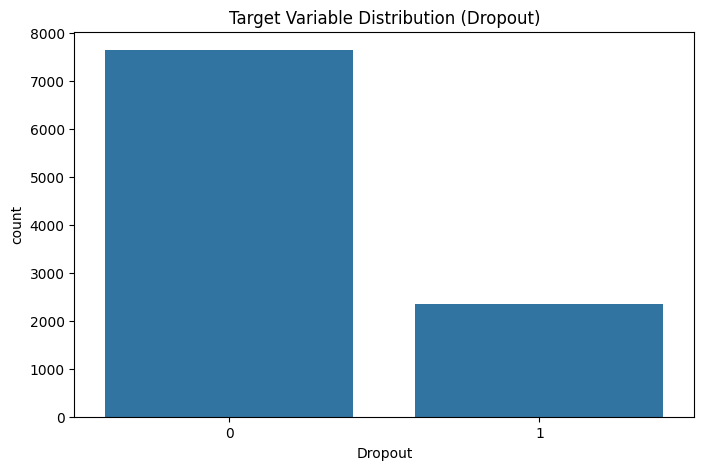

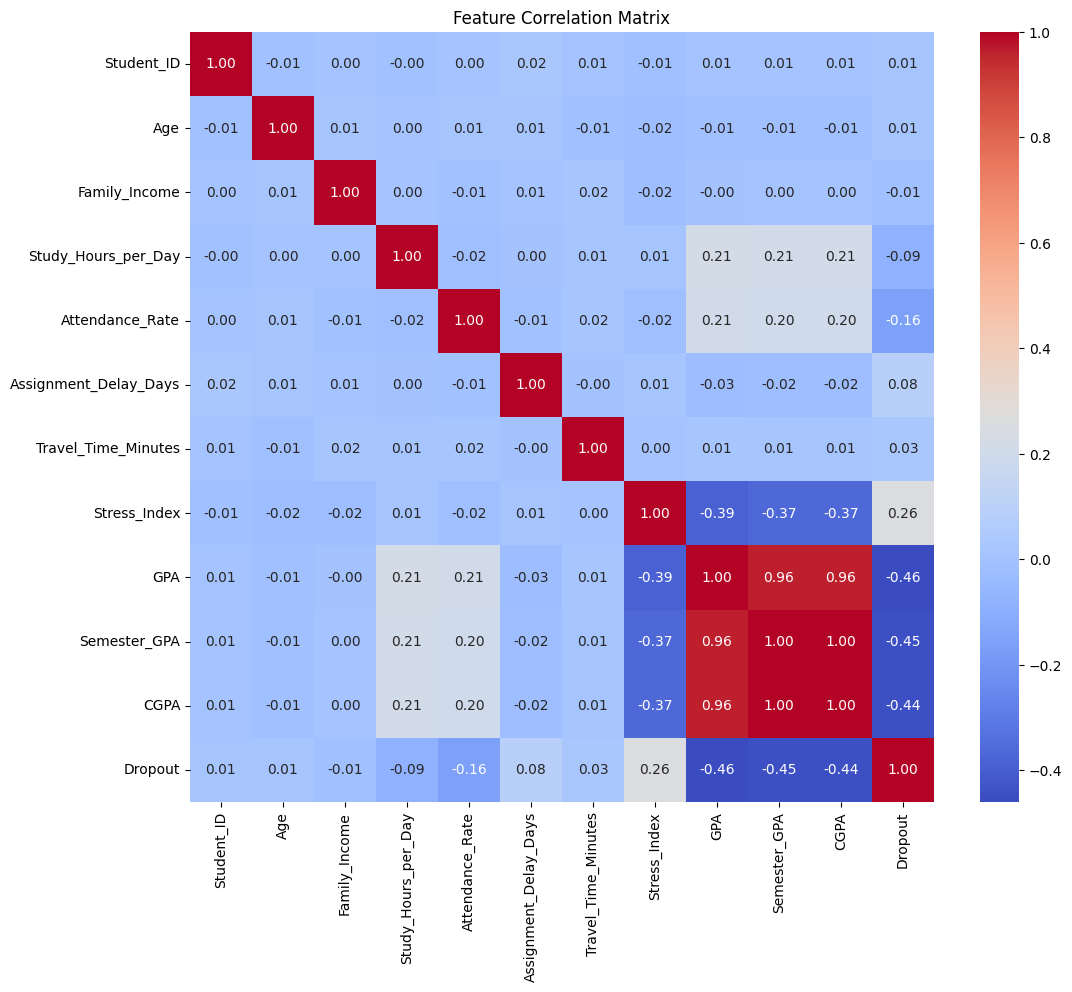

In [ ]:
# Basic statistics for numerical data
print(df.describe())

# Checking for class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='Dropout', data=df)
plt.title('Target Variable Distribution (Dropout)')
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 10))

# Selecting only numerical columns
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

### Data Preprocessing
In this section, three different machine learning algorithms are implemented to compare their performance in predicting student dropout. Initially, Logistic Regression is chosen as a baseline model due to its interpretability, followed by Naive Bayes, which is based on probabilistic assumptions, and the process concludes with Random Forest as a more complex ensemble method. To optimize the models, the Grid Search method is applied in combination with 5-fold Cross-Validation on the training set. This approach identifies the optimal hyperparameters and ensures the stability of the results by avoiding issues caused by a random split of the data.

In [ ]:
# Filling missing values with the median
num_imputer = SimpleImputer(strategy='median')
df[['Family_Income', 'Study_Hours_per_Day', 'Stress_Index']] = num_imputer.fit_transform(
    df[['Family_Income', 'Study_Hours_per_Day', 'Stress_Index']]
)

cat_imputer = SimpleImputer(strategy='most_frequent')
df[['Parental_Education']] = cat_imputer.fit_transform(df[['Parental_Education']])

# Encoding categorical variables (One-Hot Encoding)
cat_cols = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Removing the Student_ID
df_final = df_final.drop('Student_ID', axis=1)

# Splitting Features (X) and Target (y)
X = df_final.drop('Dropout', axis=1)
y = df_final['Dropout']

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Selection and Implementation
At this stage, the selection and initial implementation of the three classification algorithms are performed to evaluate their ability to identify students at risk of dropping out. The Stratified k-fold Cross Validation method with 5 splits is used to ensure that each model is trained and tested on different data segments while maintaining the class proportions.This process allows for the calculation of a reliable average accuracy (CV Accuracy) for Logistic Regression, Naive Bayes, and Random Forest, providing an initial insight into the stability and generalization capability of each model before their final evaluation.

In [ ]:
# Defining k-fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

# 2. Naive Bayes (Bernoulli due to One-Hot Encoding)
nb_model = BernoulliNB()
nb_cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

# 3. Random Forest (Ensemble Method)
rf_model = RandomForestClassifier(random_state=42)
rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print(f"Logistic Regression CV Accuracy: {lr_cv_scores.mean():.4f}")
print(f"Naive Bayes CV Accuracy: {nb_cv_scores.mean():.4f}")
print(f"Random Forest CV Accuracy: {rf_cv_scores.mean():.4f}")

Logistic Regression CV Accuracy: 0.8091
Naive Bayes CV Accuracy: 0.7007
Random Forest CV Accuracy: 0.8045


### Training and Hyperparameter Tuning

In this stage, model optimization is achieved through hyperparameter tuning to reach the highest possible accuracy. he GridSearchCV method is utilized, which systematically tests different parameter combinations, such as the regularization strength ($C$) for Logistic Regression and the number of decision trees (n_estimators) for Random Forest. This procedure is executed in conjunction with a Stratified 5-fold Cross-Validation strategy, ensuring that the selected parameters lead to models that generalize well to new data and do not exhibit overfitting phenomena.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Defining the Cross-Validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Logistic Regression - Tuning the parameter C (regularization)
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000), param_grid_lr, cv=skf, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

# 2. Naive Bayes - (BernoulliNB)
nb_model = BernoulliNB()
nb_model.fit(X_train_scaled, y_train)

# 3. Random Forest - Tuning the number of trees
param_grid_rf = {'n_estimators': [50, 100, 200]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=skf, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train)

print(f"Best C for Logistic Regression: {grid_lr.best_params_}")
print(f"Best n_estimators for Random Forest: {grid_rf.best_params_}")

Best C for Logistic Regression: {'C': 1}
Best n_estimators for Random Forest: {'n_estimators': 200}


### Model Evaluation
In this final stage, the best-performing models are evaluated on the independent test set, which was not used during the training process. Key performance metrics are calculated for each algorithm, including overall Accuracy, Precision, Recall, and the F1-score, providing a comprehensive view of the predictive effectiveness. Furthermore, Confusion Matrices are generated to analyze misclassifications, alongside ROC Curves, which illustrate the models' ability to successfully distinguish between the two classes ("Stay" vs. "Dropout") across various probability thresholds.


--- Logistic Regression ---
Accuracy: 0.8155
ROC-AUC: 0.8206
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.51       471

    accuracy                           0.82      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.82      0.80      2000



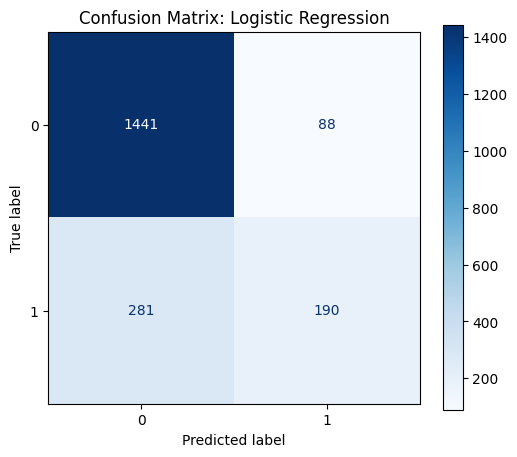

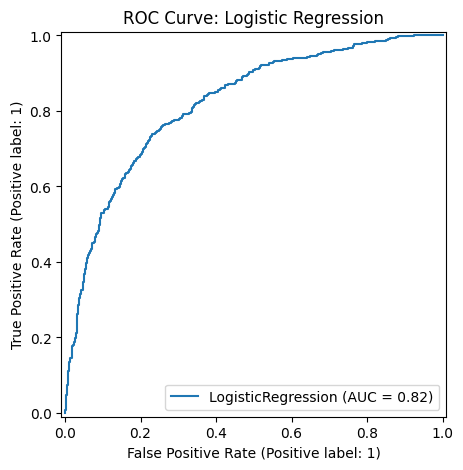


--- Naive Bayes ---
Accuracy: 0.6965
ROC-AUC: 0.7816
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1529
           1       0.42      0.78      0.55       471

    accuracy                           0.70      2000
   macro avg       0.66      0.73      0.66      2000
weighted avg       0.79      0.70      0.72      2000



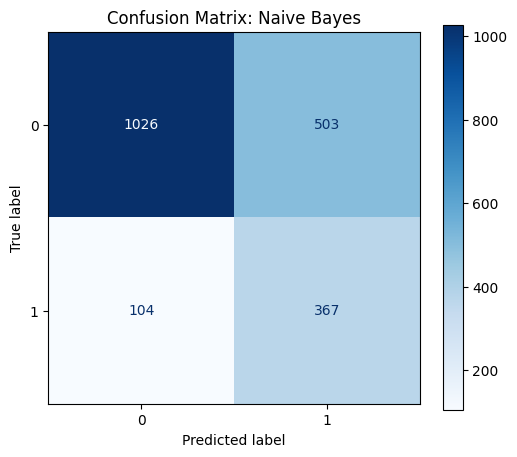

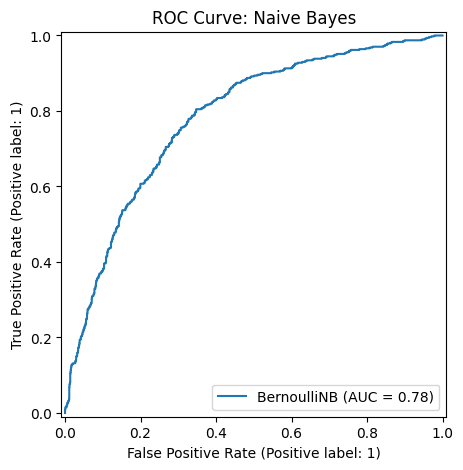


--- Random Forest ---
Accuracy: 0.8000
ROC-AUC: 0.8063
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1529
           1       0.63      0.36      0.46       471

    accuracy                           0.80      2000
   macro avg       0.73      0.65      0.67      2000
weighted avg       0.78      0.80      0.78      2000



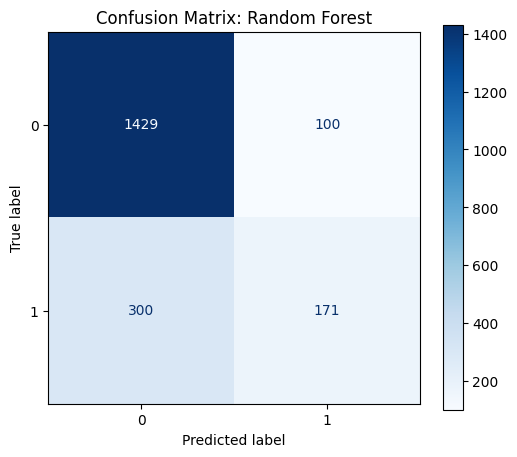

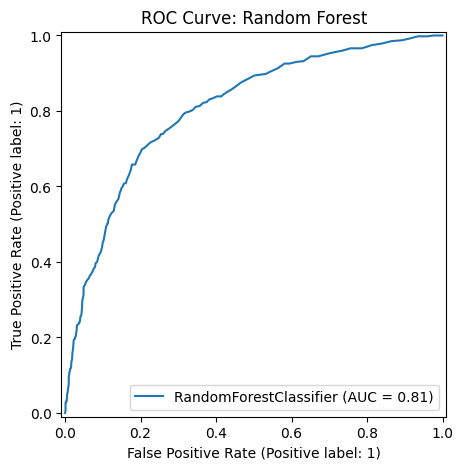

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Naive Bayes": nb_model,
    "Random Forest": grid_rf.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    # ROC Curve
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
    plt.title(f'ROC Curve: {name}')
    plt.show()